In [58]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

In [59]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'static_tests': {'target': 1, 'reference': 1},
 'dynamic_tests': {'target': 1, 'reference': 1}}

# IMPORTANDO DADOS

In [60]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_ay,target_roll,target_wx,target_tmp,target_wy,target_yaw,target_az,target_ax,target_pitch,target_wz
0,0.0,9.763089,-2.998,0.20030,30.9,0.32567,359.897,-0.474201,-0.357619,-2.215,-0.45196
1,0.1,9.763089,-2.998,0.20030,30.9,0.32567,359.897,-0.474201,-0.357619,-2.215,-0.45196
2,0.2,9.783791,-2.996,-0.36181,31.1,0.20861,359.896,-0.488303,-0.363542,-2.214,-0.08820
3,0.3,9.780937,-2.991,0.17246,30.8,-0.16146,359.897,-0.535659,-0.373682,-2.213,0.13682
4,0.4,9.789155,-2.989,-0.17076,31.2,-0.01537,359.895,-0.491343,-0.398425,-2.214,0.23667
...,...,...,...,...,...,...,...,...,...,...,...
3022,302.2,9.748153,-3.761,0.09543,45.3,-0.16747,3.876,-0.635343,-0.400602,-2.303,-0.22194
3023,302.3,9.740857,-3.763,-0.26315,45.6,-0.27232,3.877,-0.642355,-0.379625,-2.304,-0.13993
3024,302.4,9.775779,-3.765,-0.14794,45.3,0.02191,3.875,-0.640158,-0.410506,-2.305,0.23408
3025,302.5,9.754812,-3.761,0.00394,45.6,-0.11509,3.875,-0.650995,-0.376889,-2.303,-0.19104


In [61]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_ay,ref_q0,ref_wy,ref_roll,ref_wx,ref_la_pos_mon_d,ref_yaw,ref_q2,ref_az,ref_ax,ref_q3,ref_q1,ref_pitch,ref_sample_time,ref_wz
0,0.0,-9.787,1.0000,0.001553,0.001966,0.017538,0.0,-0.040646,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.003496,605000000.0,-0.004376
1,0.1,-9.787,1.0000,0.001553,0.001966,0.017538,0.0,-0.040646,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.003496,605000000.0,-0.004376
2,0.2,-9.789,1.0000,-0.000566,0.001748,0.003532,0.0,-0.040863,-0.000038,0.15230,0.01068,-0.000358,0.000016,-0.004152,705000000.0,-0.002839
3,0.3,-9.788,1.0000,-0.011780,0.002185,0.007701,0.0,-0.041299,-0.000047,0.15220,0.01081,-0.000362,0.000020,-0.005244,805000000.0,0.003741
4,0.4,-9.788,1.0000,-0.003378,0.001966,-0.008852,0.0,-0.042611,-0.000045,0.15230,0.01100,-0.000372,0.000018,-0.005026,905000000.0,-0.003298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022,302.2,-9.788,0.4250,-2.107339,91.329473,-0.534512,10.0,89.381416,0.431700,-0.08825,-0.04890,0.555200,0.569800,-15.412565,705000000.0,0.024150
3023,302.3,-9.787,0.4260,-2.117652,91.329473,-0.554910,10.0,89.152233,0.430700,-0.08842,-0.04899,0.554400,0.570600,-15.412565,805000000.0,0.041522
3024,302.4,-9.788,0.4271,-2.103328,91.329473,-0.541502,10.0,88.923050,0.429600,-0.08850,-0.04888,0.553600,0.571500,-15.406835,905000000.0,0.023864
3025,302.5,-9.787,0.4282,-2.115360,91.329473,-0.554795,10.0,88.693867,0.428600,-0.08829,-0.04897,0.552700,0.572300,-15.406835,5000000.0,0.021675


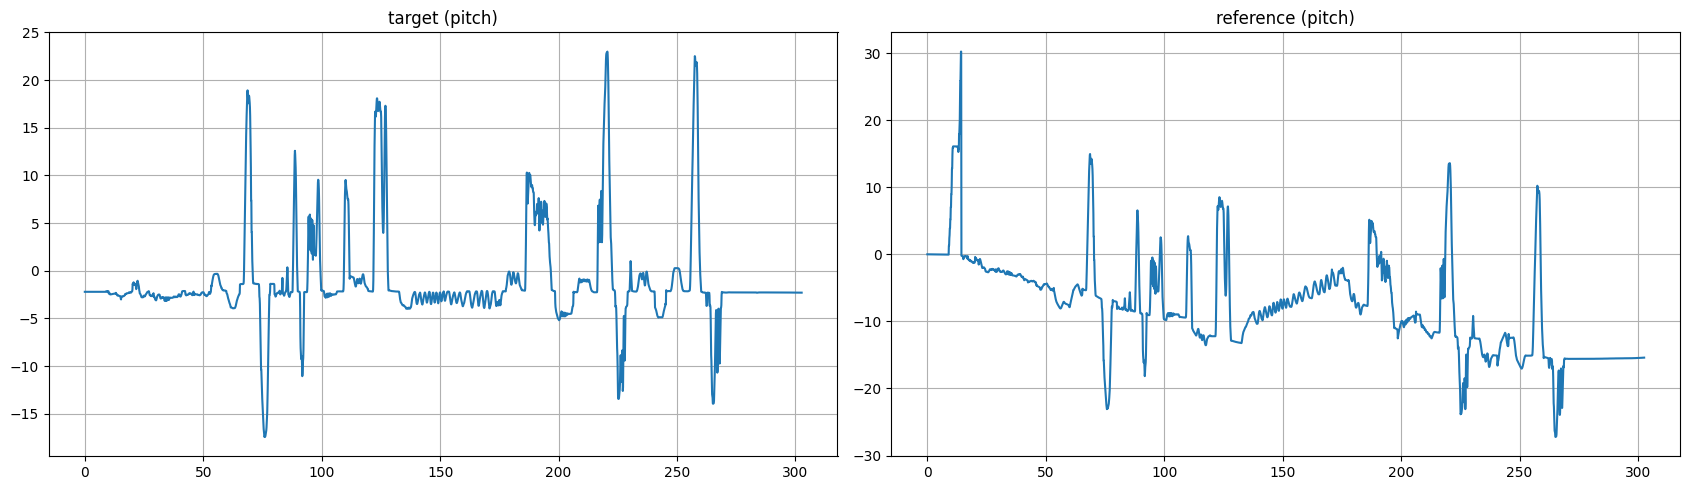

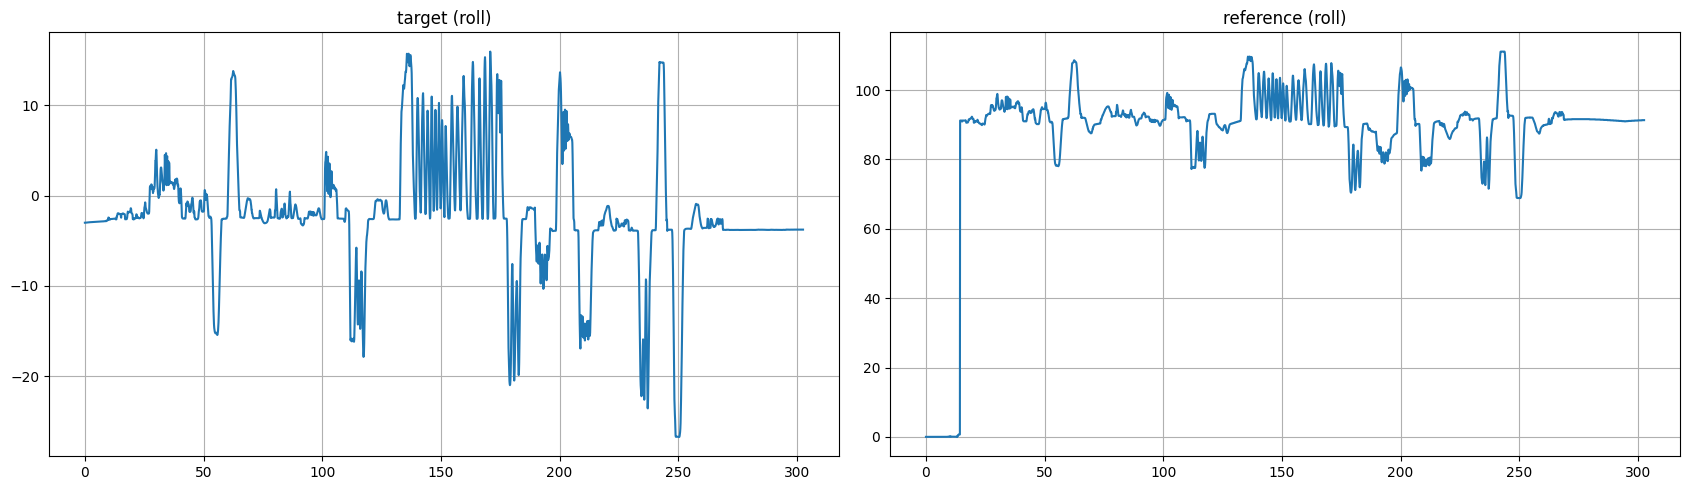

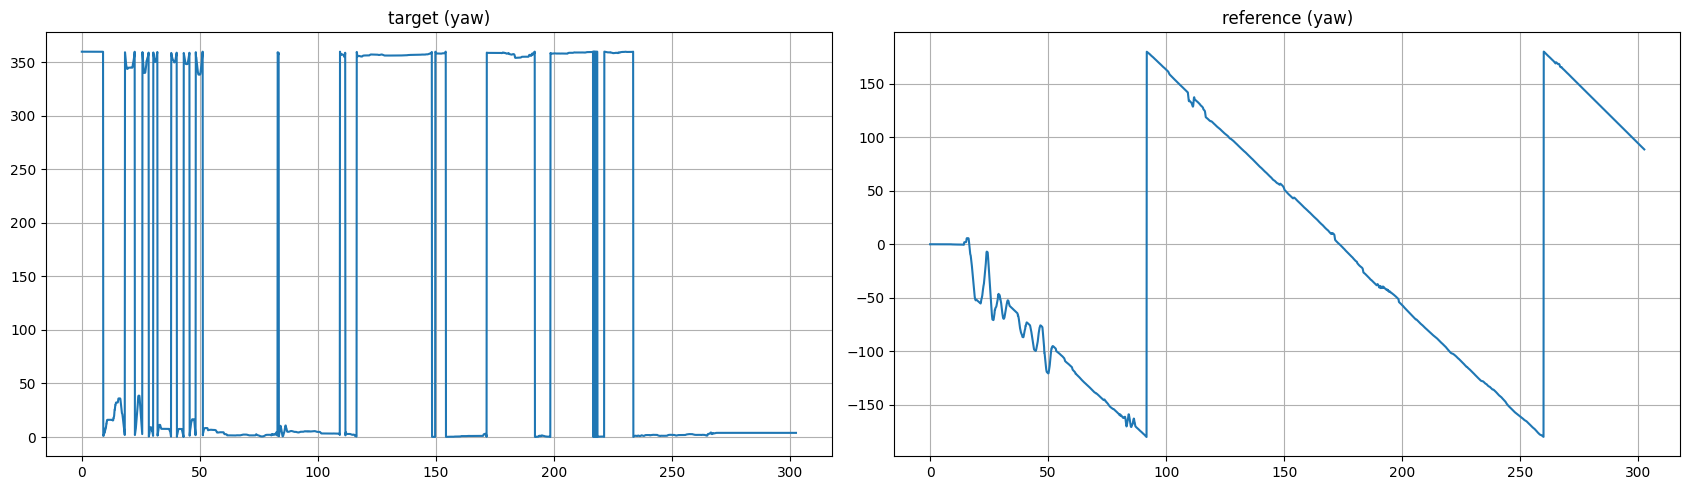

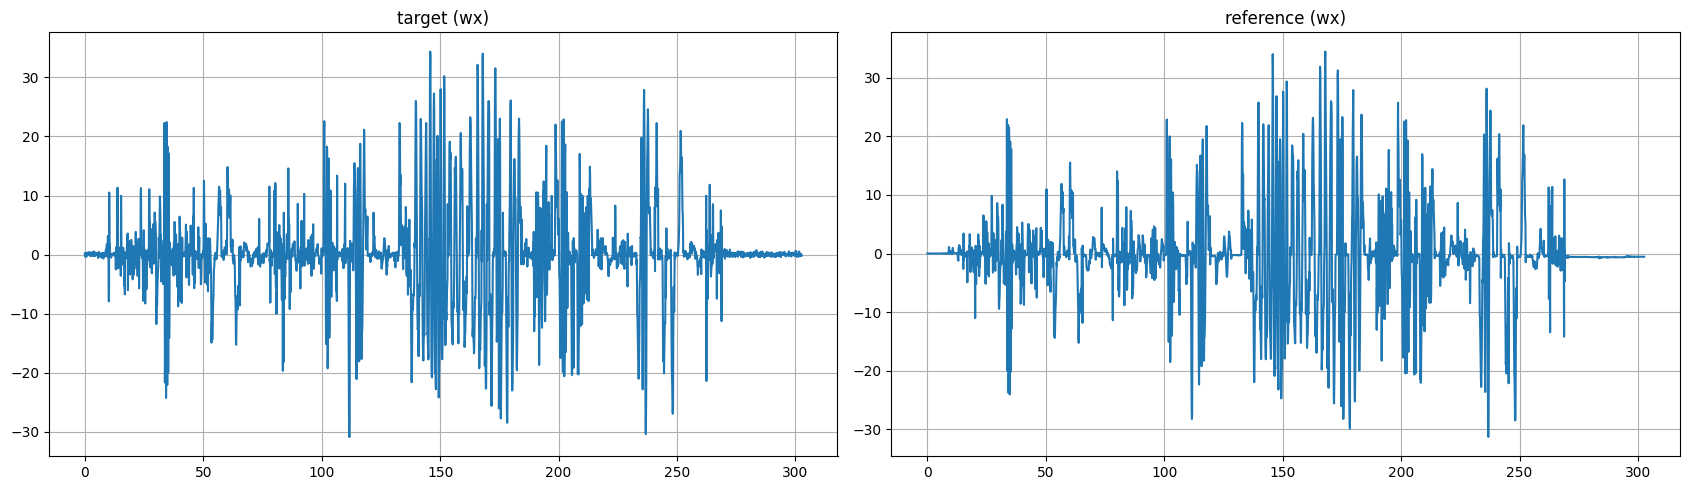

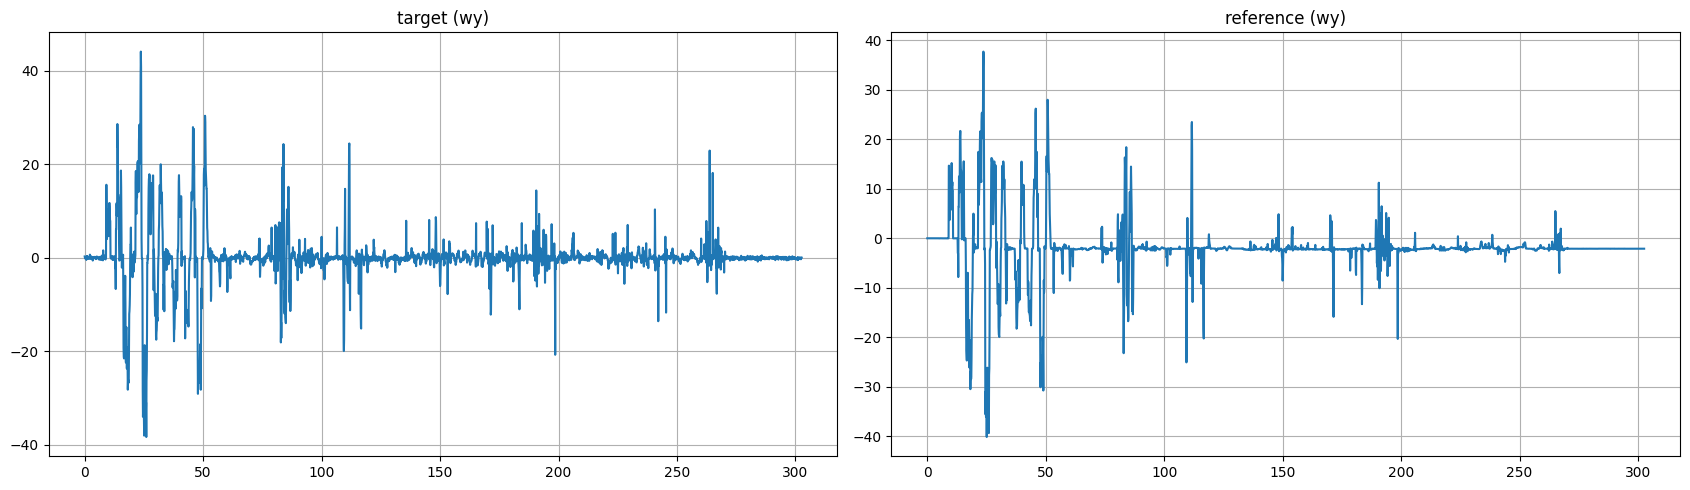

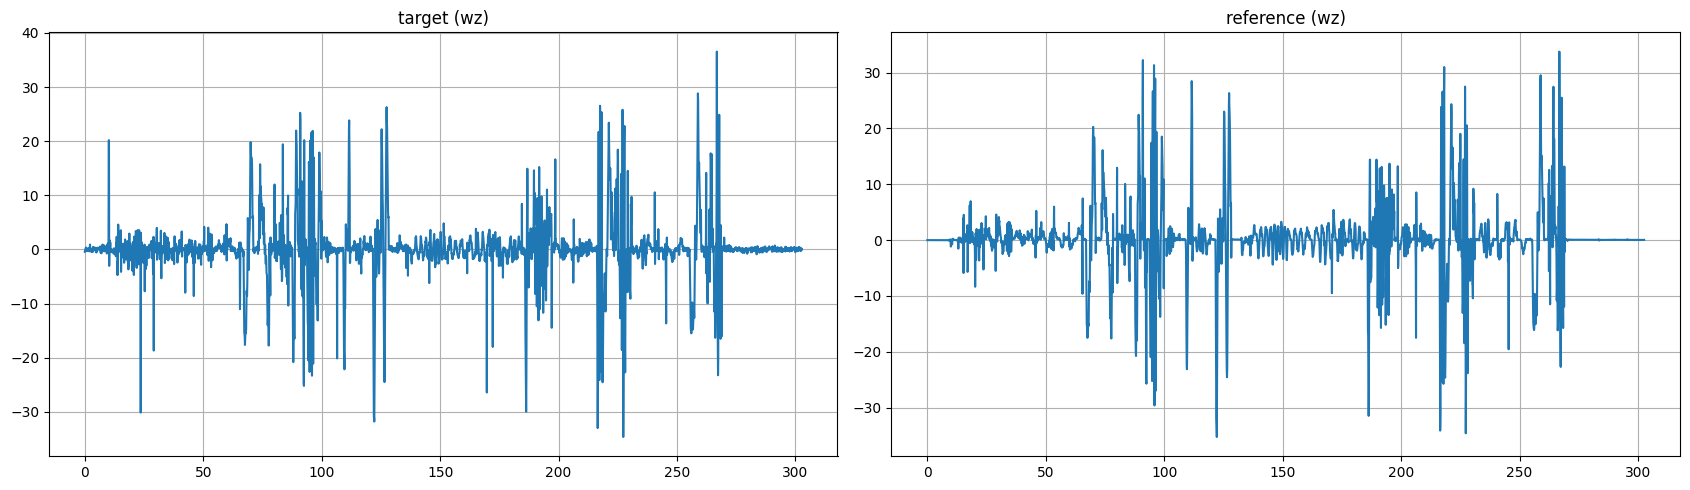

In [62]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target[f'target_{var}'], 
        f'reference ({var})': df_ref[f'ref_{var}']
    }, time=df_ref.time, figsize=(17, 5))

In [63]:
df = pd.merge_asof(df_target, df_ref, on='time', direction='nearest')
df

,time,target_ay,target_roll,target_wx,target_tmp,target_wy,target_yaw,target_az,target_ax,target_pitch,target_wz,ref_ay,ref_q0,ref_wy,ref_roll,ref_wx,ref_la_pos_mon_d,ref_yaw,ref_q2,ref_az,ref_ax,ref_q3,ref_q1,ref_pitch,ref_sample_time,ref_wz
0,0.0,9.763089,-2.998,0.20030,30.9,0.32567,359.897,-0.474201,-0.357619,-2.215,-0.45196,-9.787,1.0000,0.001553,0.001966,0.017538,0.0,-0.040646,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.003496,605000000.0,-0.004376
1,0.1,9.763089,-2.998,0.20030,30.9,0.32567,359.897,-0.474201,-0.357619,-2.215,-0.45196,-9.787,1.0000,0.001553,0.001966,0.017538,0.0,-0.040646,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.003496,605000000.0,-0.004376
2,0.2,9.783791,-2.996,-0.36181,31.1,0.20861,359.896,-0.488303,-0.363542,-2.214,-0.08820,-9.789,1.0000,-0.000566,0.001748,0.003532,0.0,-0.040863,-0.000038,0.15230,0.01068,-0.000358,0.000016,-0.004152,705000000.0,-0.002839
3,0.3,9.780937,-2.991,0.17246,30.8,-0.16146,359.897,-0.535659,-0.373682,-2.213,0.13682,-9.788,1.0000,-0.011780,0.002185,0.007701,0.0,-0.041299,-0.000047,0.15220,0.01081,-0.000362,0.000020,-0.005244,805000000.0,0.003741
4,0.4,9.789155,-2.989,-0.17076,31.2,-0.01537,359.895,-0.491343,-0.398425,-2.214,0.23667,-9.788,1.0000,-0.003378,0.001966,-0.008852,0.0,-0.042611,-0.000045,0.15230,0.01100,-0.000372,0.000018,-0.005026,905000000.0,-0.003298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022,302.2,9.748153,-3.761,0.09543,45.3,-0.16747,3.876,-0.635343,-0.400602,-2.303,-0.22194,-9.788,0.4250,-2.107339,91.329473,-0.534512,10.0,89.381416,0.431700,-0.08825,-0.04890,0.555200,0.569800,-15.412565,705000000.0,0.024150
3023,302.3,9.740857,-3.763,-0.26315,45.6,-0.27232,3.877,-0.642355,-0.379625,-2.304,-0.13993,-9.787,0.4260,-2.117652,91.329473,-0.554910,10.0,89.152233,0.430700,-0.08842,-0.04899,0.554400,0.570600,-15.412565,805000000.0,0.041522
3024,302.4,9.775779,-3.765,-0.14794,45.3,0.02191,3.875,-0.640158,-0.410506,-2.305,0.23408,-9.788,0.4271,-2.103328,91.329473,-0.541502,10.0,88.923050,0.429600,-0.08850,-0.04888,0.553600,0.571500,-15.406835,905000000.0,0.023864
3025,302.5,9.754812,-3.761,0.00394,45.6,-0.11509,3.875,-0.650995,-0.376889,-2.303,-0.19104,-9.787,0.4282,-2.115360,91.329473,-0.554795,10.0,88.693867,0.428600,-0.08829,-0.04897,0.552700,0.572300,-15.406835,5000000.0,0.021675


In [64]:
df.to_csv('output.csv', index=None)